# **Project: Laptop Price Prediction**


In this project, I analyze a dataset of laptop specifications to understand the key factors influencing laptop prices and build predictive machine learning models.
The workflow follows a complete data science pipeline, including data cleaning, exploratory data analysis (EDA), feature engineering, and model development.

Several regression techniques are applied, including:
- Simple and Multiple Linear Regression  
- Polynomial Regression  
- Ridge Regression  

Additionally, a machine learning pipeline is implemented to streamline preprocessing and model training, ensuring consistency and efficiency.

The goal is not only to build accurate predictive models but also to interpret the impact of different hardware features (such as RAM, CPU, and storage) on laptop pricing.

| Parameter |Description| Content type |
|---|----|---|
|Manifacturer| The company that manufactured the laptop| string |
|Category| The category to which the laptop belongs: Gaming, Netbook, Notebook, Ultrabook, Workstation|integer (1 to 5 respectively)|
|Screen| The name of the screen type| string |
| GPU | The manufacturer of the GPU. AMD, Intel, NVidia	| integer (1,2 or 3 respectively) |
|OS | The operating system type (Windows or Linux) | integer (1 or 2 respectively)|
|CPU_core| The type of processor used in the laptop: Intel Pentium i3, Intel Pentium i5, Intel Pentium i7 | integer (3,5 or 7 respectively)|
|Screen_Size_cm| The size of the laptop screen is recorded in inch | string| 
|CPU_frequency| The frequency at which the CPU operates, in GHz | float| 
|RAM_GB| The size of the RAM of the system in GB | integer| 
|Storage_GB_SSD| The size of the SSD storage in GB is installed in the laptop | integer| 
|Weight_kg| The weight of the laptop is in kgs| string|
|Price| The price of the laptop is in USD | integer|
 


 ## Objectives 

 ### Main Objectives
In this project, the objective is set to:
 - Load the data as a `pandas` dataframe
 - Clean the data, taking care of the blank entries
 - Run exploratory data analysis (EDA) and identify the attributes that most affect the `Price`
 - Develop single variable and multi variable Linear Regression models for predicting the `Price`
 - Use Ridge regression to refine the performance of Linear regression models. 
 
 ## Detailed Workflow 
 Part 1: Import Data set
 - Import a dataset from a CSV file to a Pandas dataframe
 - Develop some basic insights about the dataset
 
 Part 2: Data Wrangling/ pre-processing
 - Handle missing data in different ways
 - Correct the data type of different data values as per requirement
 - Standardize and normalize the appropriate data attributes
 - Visualize the data as grouped bar graph using Binning
 - Converting a categorical data into numerical indicator variables

 Part 3: Exploratory Data Analysis (EDA)
 - Visualize individual feature patterns
 - Run descriptive statistical analysis on the dataset
 - Use groups and pivot tables to find the effect of categorical variables on price
 - Use Pearson Correlation to measure the interdependence between variables

 Part 4: Model Development
 - Use Linear Regression in one variable to fit the parameters to a model
 - Use Linear Regression in multiple variables to fit the parameters to a model
 - Use Polynomial Regression in single variable tofit the parameters to a model
 - Create a pipeline for performing linear regression using multiple features in polynomial scaling
 - Evaluate the performance of different forms of regression on basis of MSE and R^2 parameters
 
 Part 5: Model Refinement
 - Use training, testing and cross validation to improve the performance of the dataset. 
 - Identify the point of overfitting of a model
 - Use Ridge Regression to identify the change in performance of a model based on its hyperparameters
 - Use Grid Search to identify the best performing model using different hyperparameters

# Setup


For this project, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### Importing Required Libraries

Importing all required libraries in one place (here):


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm

# Part 1: Import the dataset

Import the dataset into a `pandas` dataframe (Currently no headers in the CSV file). Print the first 10 rows.


In [3]:
filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_base.csv"
df = pd.read_csv(filepath, header=None)
df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.6,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.2,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.2,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
5,Dell,3,Full HD,1,1,5,39.624,1.6,8,256,2.2,1016
6,HP,3,Full HD,3,1,5,39.624,1.6,8,256,2.1,1117
7,Acer,3,IPS Panel,2,1,5,38.1,1.6,4,256,2.2,866
8,Dell,3,Full HD,1,1,5,39.624,2.5,4,256,2.3,812
9,Acer,3,IPS Panel,3,1,7,38.1,1.8,8,256,2.2,1068


Add the headers to the dataframe

In [4]:
headers= ["Manufacturer", "Category", "Screen", "GPU", "OS", "CPU_core",
"Screen_Size_cm", "CPU_frequency", "RAM_GB", "Storage_GB_SSD", "Weight_kg", "Price"]
df.columns=headers
df.head(10)

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.6,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.2,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.2,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
5,Dell,3,Full HD,1,1,5,39.624,1.6,8,256,2.2,1016
6,HP,3,Full HD,3,1,5,39.624,1.6,8,256,2.1,1117
7,Acer,3,IPS Panel,2,1,5,38.1,1.6,4,256,2.2,866
8,Dell,3,Full HD,1,1,5,39.624,2.5,4,256,2.3,812
9,Acer,3,IPS Panel,3,1,7,38.1,1.8,8,256,2.2,1068


Now, replacing the '?' entries with 'NaN' values.


In [5]:
df.replace('?',np.nan, inplace=True)

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.6,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.2,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.2,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
...,...,...,...,...,...,...,...,...,...,...,...,...
233,Lenovo,4,IPS Panel,2,1,7,35.56,2.6,8,256,1.7,1891
234,Toshiba,3,Full HD,2,1,5,33.782,2.4,8,256,1.2,1950
235,Lenovo,4,IPS Panel,2,1,5,30.48,2.6,8,256,1.36,2236
236,Lenovo,3,Full HD,3,1,5,39.624,2.5,6,256,2.4,883


# Part 2 : Data Wrangling


## 2.1 Evaluate the dataset for missing data
Missing data was last converted from '?' to numpy.NaN. Pandas uses NaN and Null values interchangeably. This means, we can just identify the entries having Null values. Let's identify which columns have missing data. 

We can simply use `dataframe.info()` to identify the columns that have some 'Null' (or NaN) information.


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Manufacturer    238 non-null    str    
 1   Category        238 non-null    int64  
 2   Screen          238 non-null    str    
 3   GPU             238 non-null    int64  
 4   OS              238 non-null    int64  
 5   CPU_core        238 non-null    int64  
 6   Screen_Size_cm  234 non-null    str    
 7   CPU_frequency   238 non-null    float64
 8   RAM_GB          238 non-null    int64  
 9   Storage_GB_SSD  238 non-null    int64  
 10  Weight_kg       233 non-null    str    
 11  Price           238 non-null    int64  
dtypes: float64(1), int64(7), str(4)
memory usage: 22.4 KB


Another way to identify missing values is with the following:
Missing data was last converted from '?' to numpy.NaN. Pandas uses NaN and Null values interchangeably. This means, we can just identify the entries having Null values

In [7]:
missing_data_df=df.isnull()
missing_data_df
for column in missing_data_df.columns.values.tolist():
        print(missing_data_df[column].value_counts())
        print("")

Manufacturer
False    238
Name: count, dtype: int64

Category
False    238
Name: count, dtype: int64

Screen
False    238
Name: count, dtype: int64

GPU
False    238
Name: count, dtype: int64

OS
False    238
Name: count, dtype: int64

CPU_core
False    238
Name: count, dtype: int64

Screen_Size_cm
False    234
True       4
Name: count, dtype: int64

CPU_frequency
False    238
Name: count, dtype: int64

RAM_GB
False    238
Name: count, dtype: int64

Storage_GB_SSD
False    238
Name: count, dtype: int64

Weight_kg
False    233
True       5
Name: count, dtype: int64

Price
False    238
Name: count, dtype: int64



## 2.2 Handle missing data:

- For continuous attributes (e.g., Weight_kg), replace missing values with the mean.
- For categorical attributes (e.g., Screen_Size_inch), replace missing values with the most frequent value.
- Update the data types of the respective columns.
- Verify the update using `df.info()`.


### Replace with mean
Missing values in attributes that have continuous data are best replaced using Mean value. We note that values in "Weight_kg" attribute are continuous in nature, and some values are missing. Therefore, we replace the missing values of weight with the average value of the attribute.

In [8]:
avg_weight_kg= df['Weight_kg'].astype("float").mean()
df.replace({'Weight_kg':np.nan}, avg_weight_kg ,inplace=True)

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.6,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.2,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.2,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
...,...,...,...,...,...,...,...,...,...,...,...,...
233,Lenovo,4,IPS Panel,2,1,7,35.56,2.6,8,256,1.7,1891
234,Toshiba,3,Full HD,2,1,5,33.782,2.4,8,256,1.2,1950
235,Lenovo,4,IPS Panel,2,1,5,30.48,2.6,8,256,1.36,2236
236,Lenovo,3,Full HD,3,1,5,39.624,2.5,6,256,2.4,883


### Replace with the most frequent value
Missing values in attributes that have categorical data are best replaced using the most frequent value. We note that values in "Screen_Size_inch" attribute are categorical in nature, and some values are missing. Therefore, we replace the missing values of Screen Size with the most frequent value of the attribute.

In [9]:
common_screen_size = df['Screen_Size_cm'].value_counts().idxmax()
df.replace({"Screen_Size_cm":np.nan},common_screen_size,inplace=True)

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.6,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.2,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.2,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
...,...,...,...,...,...,...,...,...,...,...,...,...
233,Lenovo,4,IPS Panel,2,1,7,35.56,2.6,8,256,1.7,1891
234,Toshiba,3,Full HD,2,1,5,33.782,2.4,8,256,1.2,1950
235,Lenovo,4,IPS Panel,2,1,5,30.48,2.6,8,256,1.36,2236
236,Lenovo,3,Full HD,3,1,5,39.624,2.5,6,256,2.4,883


Also note that we can update the `Screen_Size_cm` column such that all values are rounded to nearest 2 decimal places by using `numpy.round()`

In [10]:
#didn't work
df[['Screen_Size_cm']] = np.round(df[['Screen_Size_cm']],2)
df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.6,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.2,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.2,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


### Fixing the data types
Both "Weight_kg" and "Screen_Size_cm" are seen to have the data type "Object", while both of them should be having a data type of "float". Let's fix the data type of these two columns.

In [11]:
df[["Weight_kg","Screen_Size_cm"]] = df[["Weight_kg","Screen_Size_cm"]].astype("float")

## 2.3 Data Standardization
The value of Screen_size usually has a standard unit of inches. Similarly, weight of the laptop is needed to be in pounds. Use the below mentioned units of conversion and write a code to modify the columns of the dataframe accordingly. Update their names as well.

```{math}
1 inch = 2.54 cm
1 kg   = 2.205 pounds
```

In [12]:
df['Screen_Size_cm']= df["Screen_Size_cm"]/2.54
df.rename(columns={"Screen_Size_cm":"Screen_Size_inch"}, inplace=True)

In [13]:
df['Weight_kg']= df["Weight_kg"]*2.205
df.rename(columns={'Weight_kg':"Weight_pounds"}, inplace=True)

## 2.4 Data Normalization
Often it is required to normalize a continuous data attribute. Write a code to normalize the "CPU_frequency" attribute with respect to the maximum value available in the dataset.

In [14]:
df["CPU_frequency"]=df["CPU_frequency"]/df["CPU_frequency"].max()
df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price
0,Acer,4,IPS Panel,2,1,5,14.0,0.551724,8,256,3.52800,978
1,Dell,3,Full HD,1,1,3,15.6,0.689655,4,256,4.85100,634
2,Dell,3,Full HD,1,1,7,15.6,0.931034,8,256,4.85100,946
3,Dell,4,IPS Panel,2,1,5,13.3,0.551724,8,128,2.69010,1244
4,HP,4,Full HD,2,1,7,15.6,0.620690,8,256,4.21155,837


## 2.5 Binning
Binning is a process of creating a categorical attribute which splits the values of a continuous data into a specified number of groups. In this case, write a code to create 3 bins for the attribute "Price". These bins would be named "Low", "Medium" and "High". The new attribute will be named "Price-binned".

In [15]:
bins = np.linspace(min(df["Price"]), max(df["Price"]), 4)
group_names=["Low","Meduim","High"]
df["Price-binned"]=pd.cut(df["Price"],bins, labels=group_names)

Also, plot the bar graph of these bins.

Text(0.5, 1.0, 'price bins')

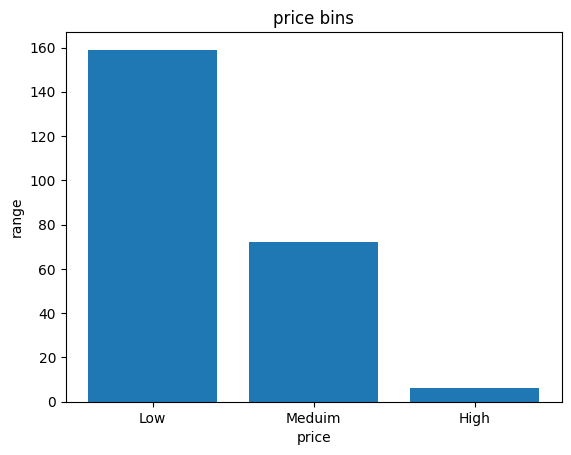

In [16]:
plt.bar(group_names, df["Price-binned"].value_counts())
plt.xlabel("price")
plt.ylabel("range")
plt.title("price bins")

## 2.6 Indicator variables
Converting the "Screen" attribute of the dataset into 2 indicator variables, "Screen-IPS_panel" and "Screen-Full_HD". Then dropping the "Screen" attribute from the dataset.

In [17]:
dummy_variable=pd.get_dummies(df["Screen"])
dummy_variable.rename(columns={"Full HD":"Screen-Full_HD", "IPS Panel":"Screen-IPS_panel"}, inplace=True)
df= pd.concat([df,dummy_variable], axis=1)
df.drop("Screen", axis=1, inplace=True)

This version of the dataset, now finalized :)

# Part 3 : Exploratory Data Analysis (EDA)

## 3.1- Visualize individual feature patterns

### Continuous valued features
Generate regression plots for each of the parameters "CPU_frequency", "Screen_Size_inch" and "Weight_pounds" against "Price". Also, print the value of correlation of each feature with "Price".

<Axes: xlabel='CPU_frequency', ylabel='Price'>

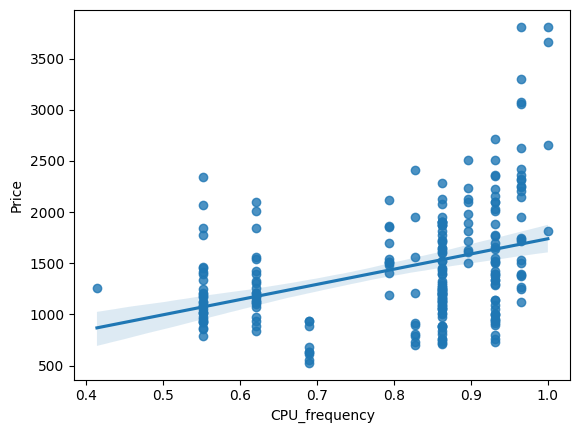

In [18]:
# CPU_frequency plot
sns.regplot(x="CPU_frequency",y="Price", data=df)

<Axes: xlabel='Screen_Size_inch', ylabel='Price'>

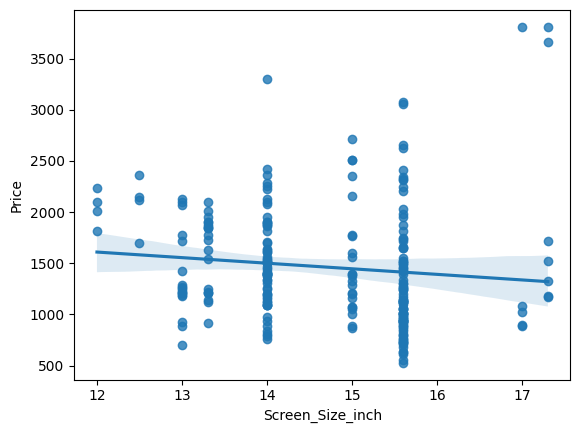

In [19]:
# Screen_Size_inch plot
sns.regplot(x='Screen_Size_inch', y='Price', data=df)

(0.0, 3974.15)

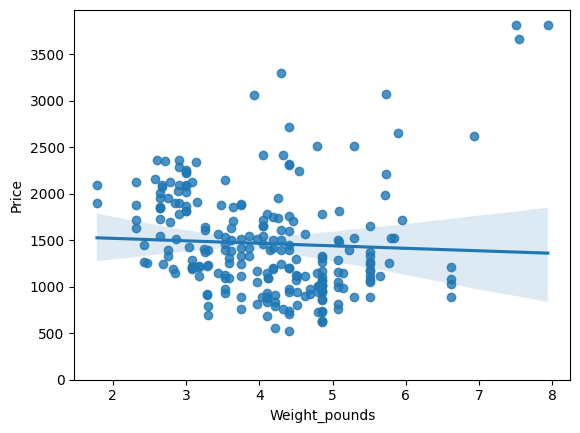

In [20]:
# Weight_pounds plot
sns.regplot(x='Weight_pounds', y='Price', data=df)
plt.ylim(0,)

Print the value of correlation of each feature with "Price".

In [21]:
for param in ["CPU_frequency","Screen_Size_inch","Weight_pounds"]:
    print(df[[param, "Price"]].corr())

               CPU_frequency     Price
CPU_frequency       1.000000  0.366666
Price               0.366666  1.000000
                  Screen_Size_inch     Price
Screen_Size_inch          1.000000 -0.110644
Price                    -0.110644  1.000000
               Weight_pounds     Price
Weight_pounds       1.000000 -0.050312
Price              -0.050312  1.000000


=> "CPU_frequency" has a 36% positive correlation with the price of the laptops. The other two parameters have weak correlation with price.

### Interpretation

The correlation analysis shows that RAM, CPU frequency, and storage capacity have the strongest positive relationship with laptop price.

This indicates that performance-related features are key drivers of price, which aligns with real-world expectations in the laptop market.

### Categorical features
Generate Box plots for the different feature that hold categorical values. These features would be "Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"

<Axes: xlabel='Category', ylabel='Price'>

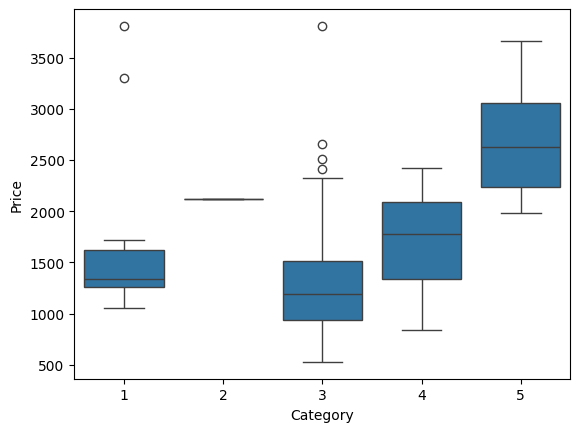

In [22]:
# Category Box plot
sns.boxplot(x="Category", y="Price", data=df)

<Axes: xlabel='GPU', ylabel='Price'>

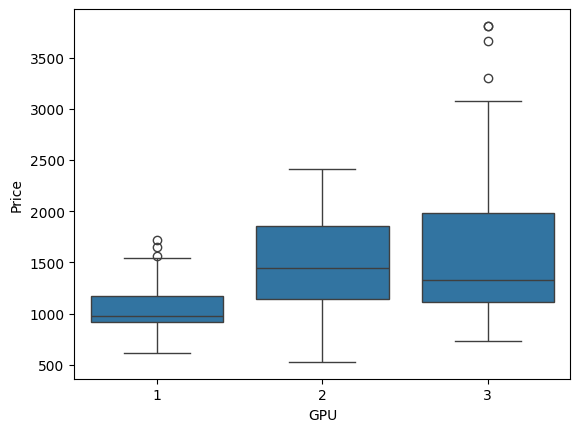

In [23]:
# GPU Box plot
sns.boxplot(x="GPU", y="Price", data=df)

<Axes: xlabel='OS', ylabel='Price'>

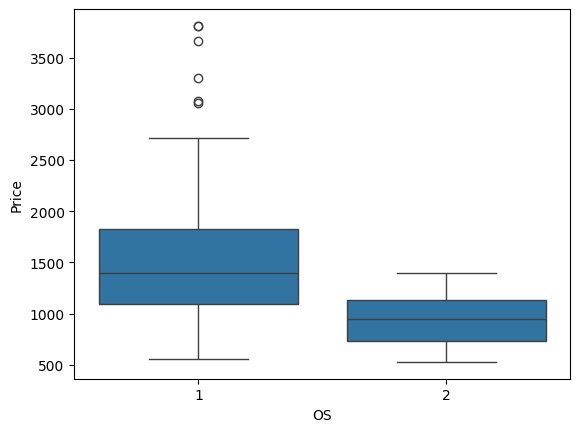

In [24]:
# OS Box plot
sns.boxplot(x="OS", y="Price", data=df)

<Axes: xlabel='CPU_core', ylabel='Price'>

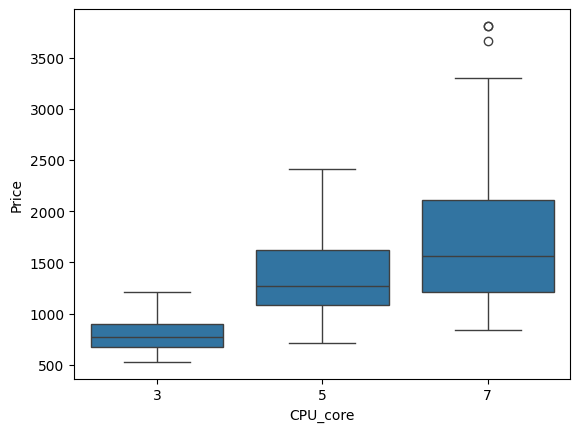

In [25]:
# CPU_core Box plot
sns.boxplot(x="CPU_core", y="Price", data=df)

<Axes: xlabel='RAM_GB', ylabel='Price'>

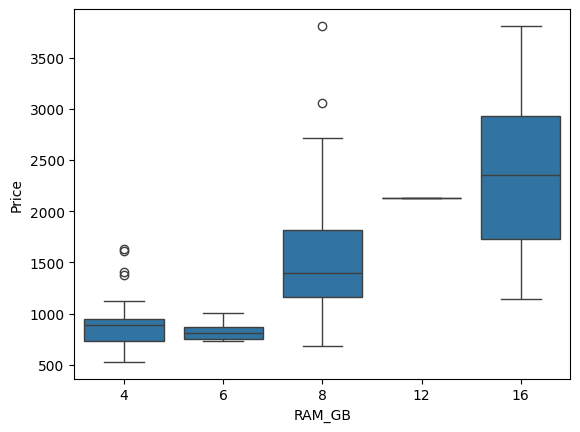

In [26]:
# RAM_GB Box plot
sns.boxplot(x="RAM_GB", y="Price", data=df)

<Axes: xlabel='Storage_GB_SSD', ylabel='Price'>

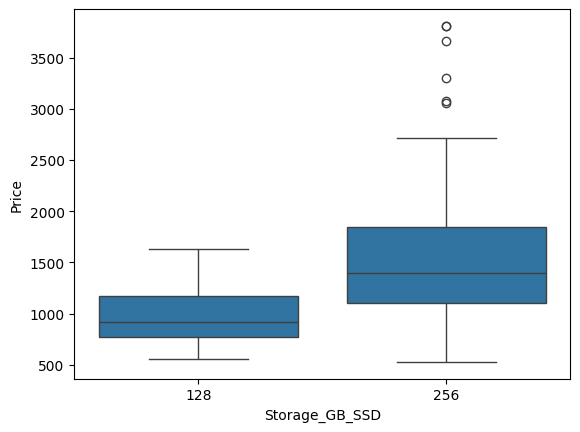

In [27]:
# Storage_GB_SSD Box plot
sns.boxplot(x="Storage_GB_SSD", y="Price", data=df)

### Interpretation

From the visualizations, it is clear that laptops with higher RAM and faster CPUs tend to have higher prices.

Additionally, certain categories such as gaming and workstation laptops appear to be priced higher on average, suggesting that laptop type also influences pricing.

## 3.2 - Descriptive Statistical Analysis

Generate the statistical description of all the features being used in the data set. Include "object" data types as well.

In [28]:
df.describe(include="all")

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
count,238,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,237,238,238
unique,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,2
top,Dell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,True,False
freq,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,159,161,161
mean,NaN,3.205882,2.151261,1.058824,5.630252,14.688655,0.813822,7.882353,245.781513,4.106221,1462.344538,NaN,NaN,NaN
std,NaN,0.776533,0.638282,0.235790,1.241787,1.166045,0.141860,2.482603,34.765316,1.078442,574.607699,NaN,NaN,NaN
min,NaN,1.000000,1.000000,1.000000,3.000000,12.000000,0.413793,4.000000,128.000000,1.786050,527.000000,NaN,NaN,NaN
25%,NaN,3.000000,2.000000,1.000000,5.000000,14.000000,0.689655,8.000000,256.000000,3.246863,1066.500000,NaN,NaN,NaN
50%,NaN,3.000000,2.000000,1.000000,5.000000,15.000000,0.862069,8.000000,256.000000,4.106221,1333.000000,NaN,NaN,NaN
75%,NaN,4.000000,3.000000,1.000000,7.000000,15.600000,0.931034,8.000000,256.000000,4.851000,1777.000000,NaN,NaN,NaN


## 3.3 - GroupBy and Pivot Tables

Group the parameters "GPU", "CPU_core" and "Price" to make a pivot table and visualize this connection using the pcolor plot.


In [29]:
# Create the group
df_group=df[["GPU","CPU_core","Price"]]
df_groupedgroup=df_group.groupby(["GPU","CPU_core"],as_index=False).mean()
df_groupedgroup

,GPU,CPU_core,Price
0,1,3,769.250000
1,1,5,998.500000
2,1,7,1167.941176
3,2,3,785.076923
4,2,5,1462.197674
5,2,7,1744.621622
6,3,3,784.000000
7,3,5,1220.680000
8,3,7,1945.097561


In [30]:
# Create the Pivot table
grouped_pivot= df_groupedgroup.pivot(index='GPU', columns='CPU_core')
grouped_pivot

Price                          
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561

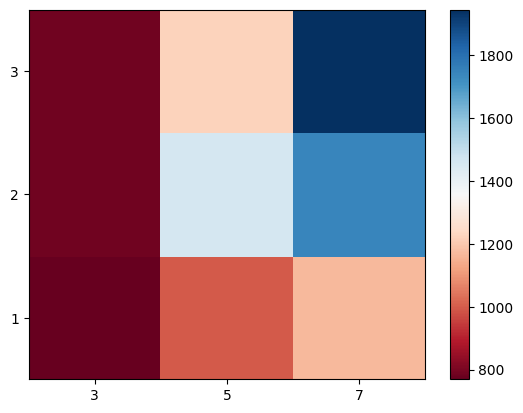

In [31]:
# Create the Plot
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)


fig.colorbar(im)
plt.show()

## 3.4 - Pearson Correlation and p-values

Use the `scipy.stats.pearsonr()` function to evaluate the Pearson Coefficient and the p-values for each parameter tested above. This will help determine the parameters most likely to have a strong effect on the price of the laptops.

In [32]:
for param in ['GPU','CPU_core','Price']:
    pearson_coef, p_value = stats.pearsonr(df[param], df["Price"])
    print("The pearson Coefficient for", param, "is" ,pearson_coef, "with p_value of", p_value)

The pearson Coefficient for GPU is 0.2882981988881427 with p_value of 6.166949698364507e-06
The pearson Coefficient for CPU_core is 0.4593977773355115 with p_value of 7.912950127009037e-14
The pearson Coefficient for Price is 0.9999999999999999 with p_value of 0.0


# Part 4 : Model Development


## 4.1 : Single Linear Regression

We have learnt that "CPU_frequency" is the parameter with the lowest p-value among the different features of the dataset. Create a single feature Linear Regression model that fits the pair of "CPU_frequency" and "Price" to find the model for prediction.

In [33]:
lm= LinearRegression()
X=df[['CPU_frequency']]
Y=df['Price']
lm.fit(X,Y)
Yhat=lm.predict(X)

Generate the Distribution plot for the predicted values and that of the actual values. Let's see how well did the model perform?

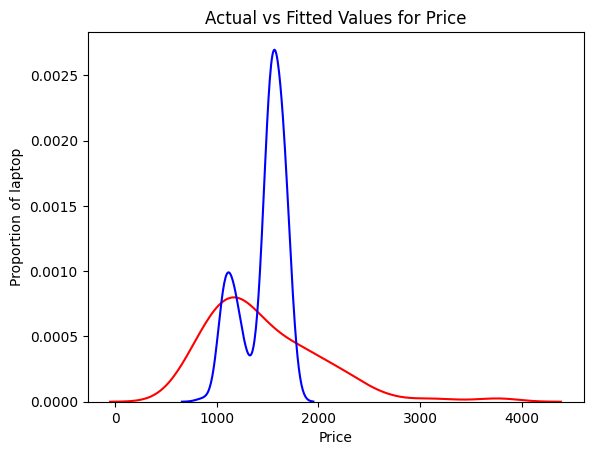

In [34]:
ax1 = sns.kdeplot(Y, color="r", label="Actual Value")
sns.kdeplot(Yhat, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptop')

plt.show()
plt.close()

Evaluate the Mean Squared Error and R^2 score values for the model. 

In [35]:
print('The R-square is: ', lm.score(X, Y))
mse = mean_squared_error(df['Price'], Yhat)
print('The mean square error of price and predicted value is: ', mse)

The R-square is:  0.1344436321024326
The mean square error of price and predicted value is:  284583.4405868629


### Interpretation

The simple linear regression model shows a limited ability to predict laptop prices using a single feature.

This suggests that laptop pricing depends on multiple factors rather than one dominant variable.

##  4.2 - Multiple Linear Regression
The parameters which have a low enough p-value so as to indicate strong relationship with the 'Price' value are 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU' and 'Category'. Use all these variables to create a Multiple Linear Regression system. 


In [36]:
Z= df[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU' , 'Category']]
lmR=LinearRegression()
lmR.fit(Z,df[['Price']])
YhatR=lmR.predict(Z)

Plot the Distribution graph of the predicted values as well as the Actual values

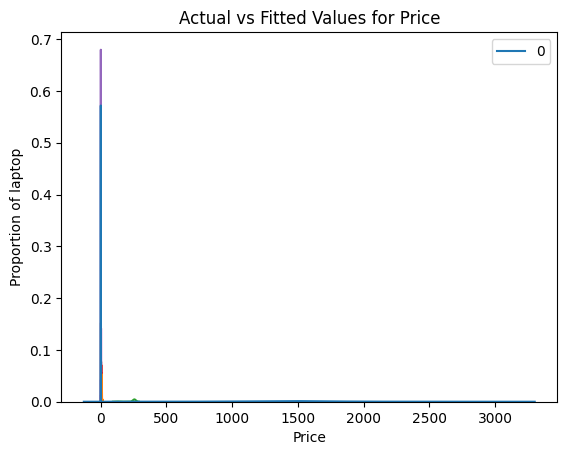

In [37]:
ax1 = sns.kdeplot(Z, color="r", label="Actual Value")
sns.kdeplot(YhatR, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptop')

plt.show()
plt.close()

Find the R^2 score and the MSE value for this fit. Is this better or worst than the performance of Single Linear Regression?


In [38]:
print('The R-square is: ', lmR.score(Z, df[['Price']]))
mseR = mean_squared_error(df['Price'], YhatR)
print('The mean square error of price and predicted value is: ', mseR)

The R-square is:  0.5082509055187374
The mean square error of price and predicted value is:  161680.57263893107


### Interpretation

The multiple linear regression model improves prediction performance by combining several features.

This confirms that laptop price is influenced by a combination of specifications rather than a single attribute.

## 4.3 - Polynomial Regression
Use the variable "CPU_frequency" to create Polynomial features. Try this for 3 different values of polynomial degrees. Remember that polynomial fits are done using `numpy.polyfit`. 

In [39]:
X = X.to_numpy().flatten()

f1 = np.polyfit(X, Y, 1)
p1 = np.poly1d(f1)

f3 = np.polyfit(X, Y, 3)
p3 = np.poly1d(f3)

f5 = np.polyfit(X, Y, 5)
p5 = np.poly1d(f5)

Plot the regression output against the actual data points to note how the data fits in each case. To plot the polynomial response over the actual data points, you have the function shown below.

In [40]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(independent_variable.min(),independent_variable.max(),100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title(f'Polynomial Fit for Price ~ {Name}')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of laptops')

Call this function for the 3 models created and get the required graphs.

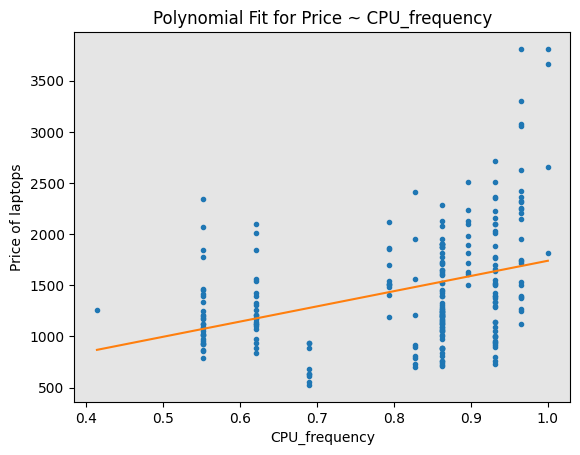

In [41]:
PlotPolly(p1, X, Y, 'CPU_frequency')

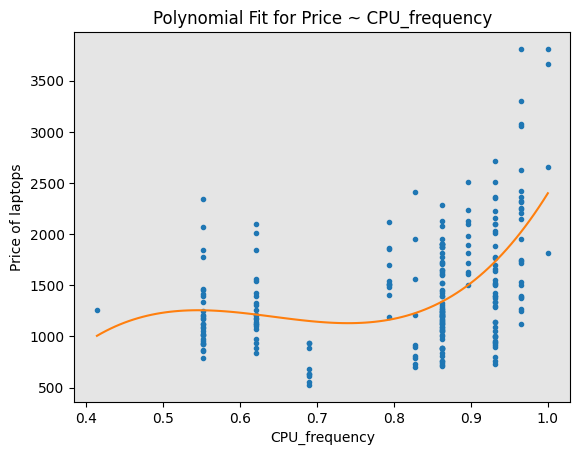

In [42]:
PlotPolly(p3, X, Y, 'CPU_frequency')

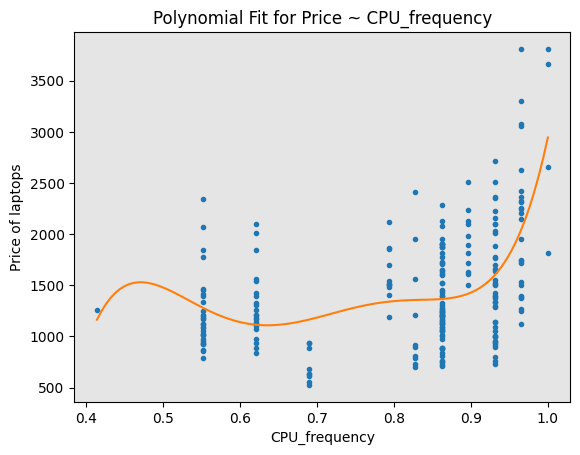

In [43]:
PlotPolly(p5, X, Y, 'CPU_frequency')

Also, calculate the R^2 and MSE values for these fits. For polynomial functions, the function sklearn.metrics.r2_score will be used to calculate R^2 values.

In [44]:
r_squared_1 = r2_score(Y, p1(X))
print('The R-square value for 1st degree polynomial is: ', r_squared_1)
print('The MSE value for 1st degree polynomial is: ', mean_squared_error(Y,p1(X)))
r_squared_3 = r2_score(Y, p3(X))
print('The R-square value for 3rd degree polynomial is: ', r_squared_3)
print('The MSE value for 3rd degree polynomial is: ', mean_squared_error(Y,p3(X)))
r_squared_5 = r2_score(Y, p5(X))
print('The R-square value for 5th degree polynomial is: ', r_squared_5)
print('The MSE value for 5th degree polynomial is: ', mean_squared_error(Y,p5(X)))

The R-square value for 1st degree polynomial is:  0.1344436321024326
The MSE value for 1st degree polynomial is:  284583.4405868629
The R-square value for 3rd degree polynomial is:  0.2669264079653101
The MSE value for 3rd degree polynomial is:  241024.86303848805
The R-square value for 5th degree polynomial is:  0.30308227064438553
The MSE value for 5th degree polynomial is:  229137.29548053656


### Interpretation

Polynomial regression captures non-linear relationships between features and price, leading to improved model performance.

However, higher-degree models may introduce overfitting, especially when the model becomes too sensitive to training data.

## 4.4 - Pipeline
Create a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression. Use the set of multiple features as before to create this pipeline. 


In [45]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)

Evaluate the MSE and R^2 values for the this predicted output.

In [46]:
print('MSE for multi-variable polynomial pipeline is: ', mean_squared_error(Y, ypipe))
print('R^2 for multi-variable polynomial pipeline is: ', r2_score(Y, ypipe))

MSE for multi-variable polynomial pipeline is:  120595.86128028373
R^2 for multi-variable polynomial pipeline is:  0.6332094535859658


The values of R^2 increase as we go from Single Linear Regression to Multiple Linear Regression. Further, if we go for multiple linear regression extended with polynomial features, we get an even better R^2 value.

### Interpretation

The use of a pipeline allows for a streamlined and consistent workflow by combining preprocessing steps and model training.

This reduces the risk of errors and ensures that transformations are applied correctly during both training and testing.

# Part 5 : Model Refinement


## 5.1 Using Cross validation to improve the model

Divide the dataset into x_data and y_data parameters. Here y_data is the "Price" attribute, and x_data has all other attributes in the data set.

In [47]:
y_data=df['Price']
x_data=df.drop('Price',axis=1)

Split the data set into training and testing subests such that you reserve 10% of the data set for testing purposes.

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1)
print("number of test samples :", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples : 24
number of training samples: 214


Create a single variable linear regression model using "CPU_frequency" parameter. Print the R^2 value of this model for the training and testing subsets.

In [49]:
lre=LinearRegression()
lre.fit(x_train[['CPU_frequency']], y_train)
lre.score(x_train[['CPU_frequency']], y_train)
lre.score(x_test[['CPU_frequency']], y_test)

-0.06599437350393766

Run a 4-fold cross validation on the model and print the mean value of R^2 score along with its standard deviation.


In [50]:
Rcross = cross_val_score(lre, x_train[['CPU_frequency']], y_train, cv=4)
print("The mean of the folds are", Rcross.mean(), "and the standard deviation is" , Rcross.std())

The mean of the folds are 0.1273881801955502 and the standard deviation is 0.08317058010912029


## 5.2 Overfitting

Split the data set into training and testing components again, this time reserving 50% of the data set for testing.


In [51]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x_data, y_data, test_size=0.50, random_state=0)
print("number of test samples :", x_test1.shape[0])
print("number of training samples:",x_train1.shape[0])

number of test samples : 119
number of training samples: 119


To identify the point of overfitting the model on the parameter "CPU_frequency", you'll need to create polynomial features using the single attribute. 
You need to evaluate the R^2 scores of the model created using different degrees of polynomial features, ranging from 1 to 5. Save this set of values of R^2 score as a list.


In [52]:
lre = LinearRegression()
Rsqu_test = []
order = [1, 2, 3, 4, 5]
for n in order:
    pr = PolynomialFeatures(degree=n)
    x_train_pr = pr.fit_transform(x_train[['CPU_frequency']])
    x_test_pr = pr.fit_transform(x_test[['CPU_frequency']])    
    lre.fit(x_train_pr, y_train)
    Rsqu_test.append(lre.score(x_test_pr, y_test))

Plot the values of R^2 scores against the order. Note the point where the score drops.


Text(0.5, 1.0, 'R^2 Using Test Data')

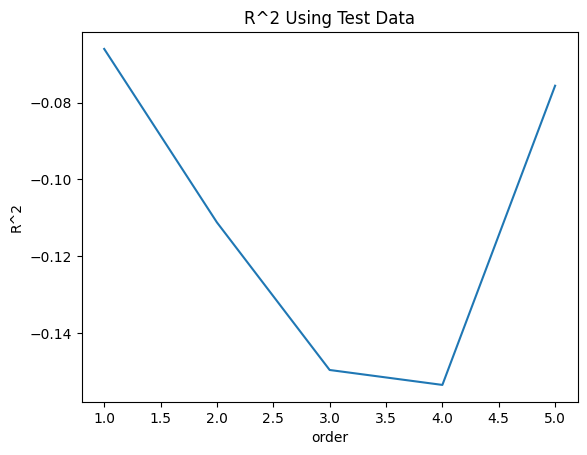

In [53]:
plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')  

### Interpretation

The evaluation metrics indicate how well the model explains the variability in laptop prices.

A higher R² score suggests better predictive performance, while lower MSE indicates more accurate predictions.

## 5.3 Ridge Regression

Now consider that you have multiple features, i.e. 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU' and 'Category'. Create a polynomial feature model that uses all these parameters with degree=2. Also create the training and testing attribute sets.


In [54]:
pr1 = PolynomialFeatures(degree=2)
x_train_pr1 = pr1.fit_transform(x_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']])
x_test_pr1 = pr1.fit_transform(x_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']])

Create a Ridge Regression model and evaluate it using values of the hyperparameter alpha ranging from 0.001 to 1 with increments of 0.001. 
Create a list of all Ridge Regression R^2 scores for training and testing data. 

In [55]:
Rsqu_test = []
Rsqu_train = []
Alpha = np.linspace(0.001, 0.999, 999)
pbar = tqdm(Alpha)

for alpha in pbar:
    RigeModel = Ridge(alpha=alpha) 
    RigeModel.fit(x_train_pr, y_train)
    test_score, train_score = RigeModel.score(x_test_pr, y_test), RigeModel.score(x_train_pr, y_train)
    
    pbar.set_postfix({"Test Score": test_score, "Train Score": train_score})

    Rsqu_test.append(test_score)
    Rsqu_train.append(train_score)

100%|██████████| 999/999 [00:01<00:00, 851.47it/s, Test Score=-0.0813, Train Score=0.247] 


Plot the R^2 values for training and testing sets with respect to the value of alpha


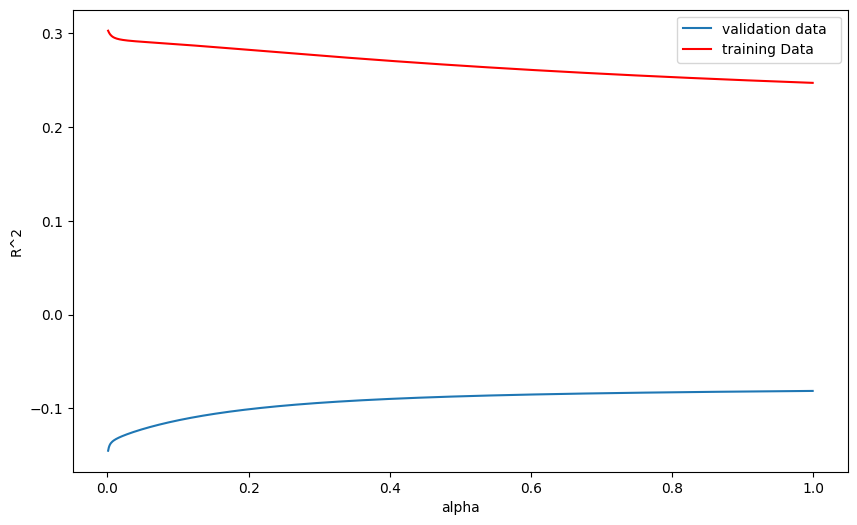

In [56]:
width = 10
height = 6
plt.figure(figsize=(width, height))

plt.plot(Alpha,Rsqu_test, label='validation data  ')
plt.plot(Alpha,Rsqu_train, 'r', label='training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()

### Interpretation

Ridge Regression helps reduce overfitting by penalizing large coefficients in the model.

This leads to a more stable and generalizable model, especially when working with polynomial features.

## 5.4 Grid Search

Using the raw data and the same set of features as used above, use GridSearchCV to identify the value of alpha for which the model performs best. 
Assume the set of alpha values to be used as
```math
{0.0001, 0.001, 0.01, 0.1, 1, 10}
```

In [57]:
parameters1= [{'alpha': [0.0001,0.001,0.01,0.1,1,10]}]

Create a Ridge instance and run Grid Search using a 4 fold cross validation.

In [58]:
RR=Ridge()
Grid1 = GridSearchCV(RR, parameters1,cv=4)

Fit the Grid Search to the training data.

In [59]:
Grid1.fit(x_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']], y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'alpha': [0.0001, 0.001, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are 

Print the R^2 score for the test data using the estimator that uses the derived optimum value of alpha.

In [60]:
BestRR=Grid1.best_estimator_
print(BestRR.score(x_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU','Category']], y_test))

0.24478039817907093


# End of the project


## Final Conclusion

In this project, multiple regression techniques were applied to predict laptop prices based on their technical specifications.

The best performing model was Ridge Regression combined with polynomial features, as it provided a good balance between model complexity and generalization.

The analysis showed that RAM, CPU frequency, and storage are among the most important factors influencing laptop prices.

Additionally, the use of pipelines improved the efficiency and reliability of the modeling process by integrating preprocessing and model training into a single workflow.

Overall, this project demonstrates a complete machine learning workflow, from data cleaning and exploration to model building and evaluation.

<h3> Inspired by the training of IBM Data Analyst with Python. Certified in April 2026 </h3>
